In [8]:
import pandas as pd

df_sub = pd.read_csv("/home/users/yao.wei/Desktop/cyp_toxicogenomics/zinc/substrate_toxic_dataset.txt")

df_sub.head()

len(df_sub)


157946475

In [4]:
len(df_sub)

73276767

In [10]:
import pandas as pd

df_inh = pd.read_csv("/home/users/yao.wei/Desktop/cyp_toxicogenomics/zinc/inhibitor_toxic_dataset.txt")

df_inh.head()

len(df_inh)



80042361

In [9]:
import pandas as pd

df = pd.read_csv("/home/users/yao.wei/Desktop/cyp_toxicogenomics/zinc/inhibitor_toxic_dataset_03.txt", sep='\t')

df.columns = df.columns.str.strip()  # Clean up whitespace
print(df.columns.tolist())           # Confirm column names

average_similarity = df["Similarity"].mean()
print("Average Similarity:", average_similarity)


['SMILES', 'ZINC_ID', 'Similarity']
Average Similarity: 0.3344950995705176


In [7]:
len(df)

1043582

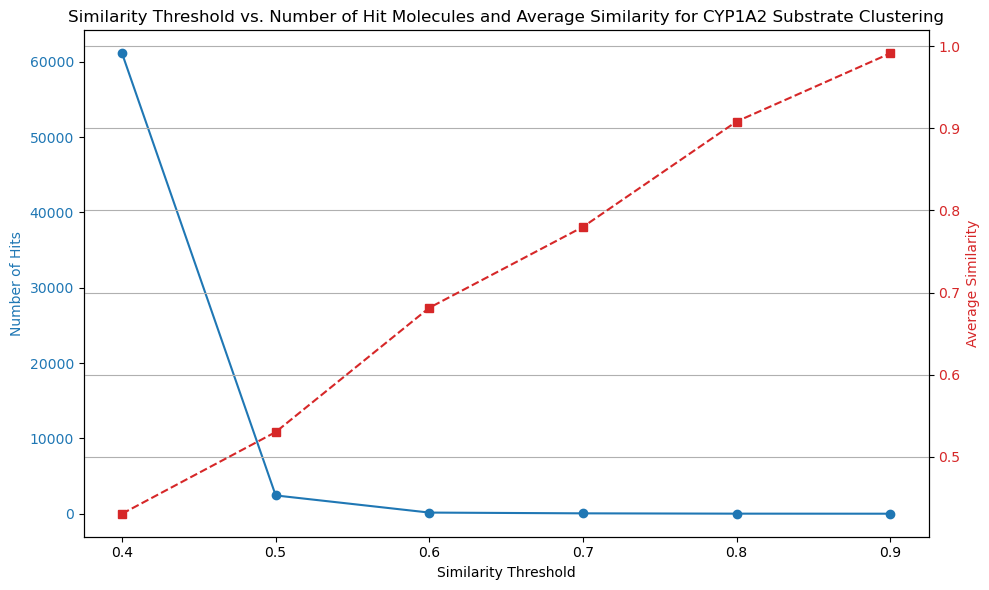

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

inh_04 = pd.read_csv("/home/users/yao.wei/Desktop/cyp_toxicogenomics/zinc/inhibitor_toxic_dataset_04.txt", sep='\t')
inh_05 = pd.read_csv("/home/users/yao.wei/Desktop/cyp_toxicogenomics/zinc/inhibitor_toxic_dataset_05.txt", sep='\t')
inh_06 = pd.read_csv("/home/users/yao.wei/Desktop/cyp_toxicogenomics/zinc/inhibitor_toxic_dataset_06.txt", sep='\t')
inh_07 = pd.read_csv("/home/users/yao.wei/Desktop/cyp_toxicogenomics/zinc/inhibitor_toxic_dataset_07.txt", sep='\t')
inh_08 = pd.read_csv("/home/users/yao.wei/Desktop/cyp_toxicogenomics/zinc/inhibitor_toxic_dataset_08.txt", sep='\t')
inh_09 = pd.read_csv("/home/users/yao.wei/Desktop/cyp_toxicogenomics/zinc/inhibitor_toxic_dataset_09.txt", sep='\t')

inh_05.columns = inh_05.columns.str.strip()
inh_06.columns = inh_06.columns.str.strip()
inh_07.columns = inh_07.columns.str.strip()
inh_08.columns = inh_08.columns.str.strip()
inh_09.columns = inh_09.columns.str.strip()


# Step 1: Sample Data 
thresholds = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
num_hits = [len(inh_04), len(inh_05), len(inh_06), len(inh_07), len(inh_08), len(inh_09)]  
avg_similarity = [inh_04["Similarity"].mean(), inh_05["Similarity"].mean(), inh_06["Similarity"].mean(),
                   inh_07["Similarity"].mean(), inh_08["Similarity"].mean(),
                   inh_09["Similarity"].mean()] 

# Step 2: Create DataFrame
df = pd.DataFrame({
    'Threshold': thresholds,
    'NumHits': num_hits,
    'AvgSimilarity': avg_similarity
})

# Step 3: Plot
fig, ax1 = plt.subplots(figsize=(10, 6))


color = 'tab:blue'
ax1.set_xlabel('Similarity Threshold')
ax1.set_ylabel('Number of Hits', color=color)
ax1.plot(df['Threshold'], df['NumHits'], marker='o', color=color, label='Number of Molecules')
ax1.tick_params(axis='y', labelcolor=color)


ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Average Similarity', color=color)
ax2.plot(df['Threshold'], df['AvgSimilarity'], marker='s', linestyle='--', color=color, label='Avg Similarity')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Similarity Threshold vs. Number of Hit Molecules and Average Similarity for CYP1A2 Substrate Clustering')
fig.tight_layout()
plt.grid(True)
plt.show()


In [24]:
print(avg_similarity)


[0.43037830319888726, 0.529905055487053, 0.6813885350318472, 0.7799464285714286, 0.9084, 0.9915]


In [25]:
print(len(inh_04))
print(len(inh_05))
print(len(inh_06))
print(len(inh_07))
print(len(inh_08))
print(len(inh_09))


61115
2433
157
56
15
8


[10:06:05] DEPRECATION WARNING: please use MorganGenerator
[10:06:05] DEPRECATION WARNING: please use MorganGenerator
[10:06:05] DEPRECATION WARNING: please use MorganGenerator
[10:06:05] DEPRECATION WARNING: please use MorganGenerator
[10:06:05] DEPRECATION WARNING: please use MorganGenerator
[10:06:05] DEPRECATION WARNING: please use MorganGenerator
[10:06:05] DEPRECATION WARNING: please use MorganGenerator
[10:06:05] DEPRECATION WARNING: please use MorganGenerator
[10:06:05] DEPRECATION WARNING: please use MorganGenerator
[10:06:05] DEPRECATION WARNING: please use MorganGenerator
[10:06:05] DEPRECATION WARNING: please use MorganGenerator
[10:06:05] DEPRECATION WARNING: please use MorganGenerator
[10:06:05] DEPRECATION WARNING: please use MorganGenerator
[10:06:05] DEPRECATION WARNING: please use MorganGenerator
[10:06:05] DEPRECATION WARNING: please use MorganGenerator
[10:06:05] DEPRECATION WARNING: please use MorganGenerator
[10:06:05] DEPRECATION WARNING: please use MorganGenerat

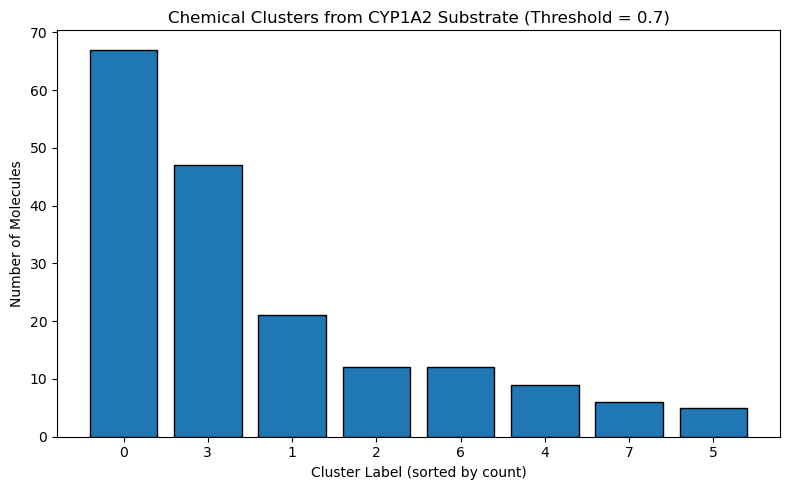

In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import umap.umap_ as umap


inh_03 = pd.read_csv("/home/users/yao.wei/Desktop/cyp_toxicogenomics/zinc/substrate_toxic_dataset_07.txt", sep='\t')

def smiles_to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    arr = np.zeros((2048,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

inh_03['Fingerprint'] = inh_03['SMILES'].apply(smiles_to_fp)
inh_03 = inh_03[inh_03['Fingerprint'].notnull()]  # Drop invalid molecules
X = np.array(list(inh_03['Fingerprint']))

reducer = umap.UMAP(random_state=42)
X_embedded = reducer.fit_transform(X)

# Clustering using KMeans
n_clusters = 8
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(X_embedded)


inh_03['Cluster'] = labels

cluster_counts = inh_03['Cluster'].value_counts().sort_values(ascending=False)
sorted_cluster_labels = cluster_counts.index.tolist()
sorted_counts = cluster_counts.values

plt.figure(figsize=(8, 5))
plt.bar(range(len(sorted_counts)), sorted_counts, tick_label=sorted_cluster_labels,
        edgecolor='black', width=0.8)
plt.title("Chemical Clusters from CYP1A2 Substrate (Threshold = 0.7)")
plt.xlabel("Cluster Label (sorted by count)")
plt.ylabel("Number of Molecules")
plt.tight_layout()
plt.show()


In [27]:
import umap
print(umap.__file__)


/home/users/yao.wei/miniforge3/lib/python3.10/site-packages/umap/__init__.py


In [32]:
import umap.umap_ as umap
reducer = umap.UMAP(random_state=42)


[10:05:22] DEPRECATION WARNING: please use MorganGenerator
[10:05:22] DEPRECATION WARNING: please use MorganGenerator
[10:05:22] DEPRECATION WARNING: please use MorganGenerator
[10:05:22] DEPRECATION WARNING: please use MorganGenerator
[10:05:22] DEPRECATION WARNING: please use MorganGenerator
[10:05:22] DEPRECATION WARNING: please use MorganGenerator
[10:05:22] DEPRECATION WARNING: please use MorganGenerator
[10:05:22] DEPRECATION WARNING: please use MorganGenerator
[10:05:22] DEPRECATION WARNING: please use MorganGenerator
[10:05:22] DEPRECATION WARNING: please use MorganGenerator
[10:05:22] DEPRECATION WARNING: please use MorganGenerator
[10:05:22] DEPRECATION WARNING: please use MorganGenerator
[10:05:22] DEPRECATION WARNING: please use MorganGenerator
[10:05:22] DEPRECATION WARNING: please use MorganGenerator
[10:05:22] DEPRECATION WARNING: please use MorganGenerator
[10:05:22] DEPRECATION WARNING: please use MorganGenerator
[10:05:22] DEPRECATION WARNING: please use MorganGenerat

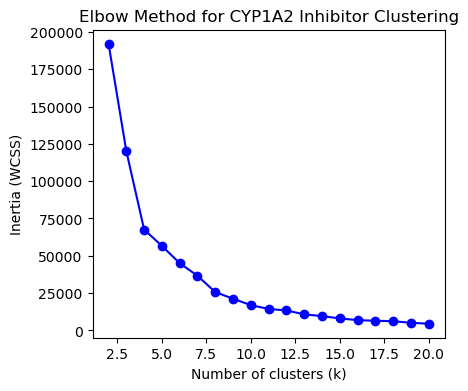

In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import umap.umap_ as umap


inh_03 = pd.read_csv("/home/users/yao.wei/Desktop/cyp_toxicogenomics/zinc/inhibitor_toxic_dataset_05.txt", sep='\t')

# Convert SMILES to Morgan fingerprints
def smiles_to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    arr = np.zeros((2048,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# Generate fingerprints
inh_03['Fingerprint'] = inh_03['SMILES'].apply(smiles_to_fp)
inh_03 = inh_03[inh_03['Fingerprint'].notnull()]  # drop invalid molecules
X = np.array(list(inh_03['Fingerprint']))


reducer = umap.UMAP(random_state=42)
X_embedded = reducer.fit_transform(X)

inertia = []
silhouette_scores = []
cluster_range = range(2, 21)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels_k = kmeans.fit_predict(X_embedded)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_embedded, labels_k))


# Plot Elbow and Silhouette Score
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(cluster_range, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for CYP1A2 Inhibitor Clustering')

plt.show()




[08:43:37] DEPRECATION WARNING: please use MorganGenerator
[08:43:37] DEPRECATION WARNING: please use MorganGenerator
[08:43:37] DEPRECATION WARNING: please use MorganGenerator
[08:43:37] DEPRECATION WARNING: please use MorganGenerator
[08:43:37] DEPRECATION WARNING: please use MorganGenerator
[08:43:37] DEPRECATION WARNING: please use MorganGenerator
[08:43:37] DEPRECATION WARNING: please use MorganGenerator
[08:43:37] DEPRECATION WARNING: please use MorganGenerator
[08:43:37] DEPRECATION WARNING: please use MorganGenerator
[08:43:37] DEPRECATION WARNING: please use MorganGenerator
[08:43:37] DEPRECATION WARNING: please use MorganGenerator
[08:43:37] DEPRECATION WARNING: please use MorganGenerator
[08:43:37] DEPRECATION WARNING: please use MorganGenerator
[08:43:37] DEPRECATION WARNING: please use MorganGenerator
[08:43:37] DEPRECATION WARNING: please use MorganGenerator
[08:43:37] DEPRECATION WARNING: please use MorganGenerator
[08:43:37] DEPRECATION WARNING: please use MorganGenerat

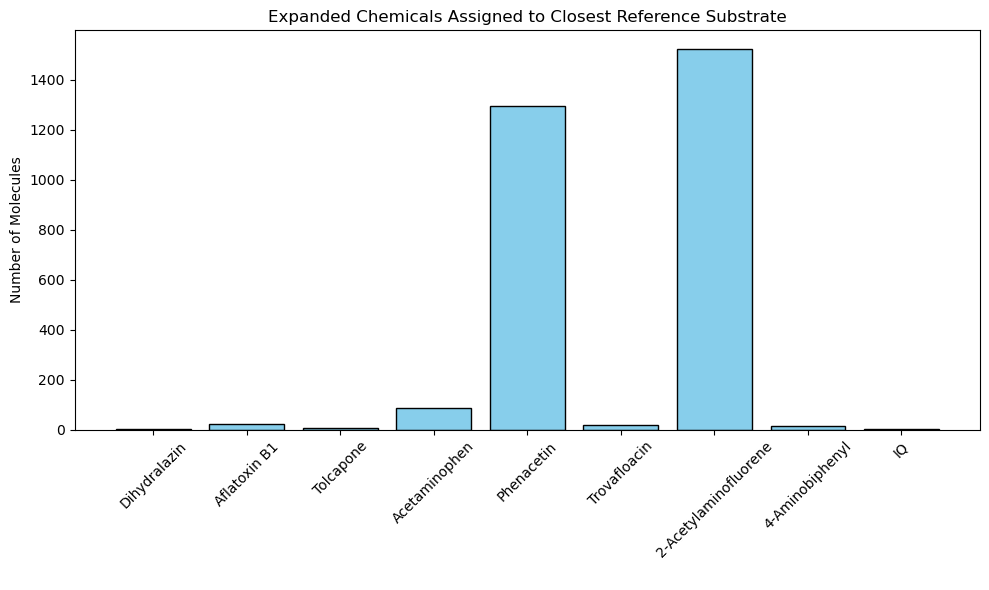

In [ ]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
import matplotlib.pyplot as plt


ref_df = pd.read_csv("/home/users/yao.wei/Desktop/cyp_toxicogenomics/zinc/ref_substrate.txt", sep='\t')
expanded_df = pd.read_csv("/home/users/yao.wei/Desktop/cyp_toxicogenomics/zinc/substrate_toxic_dataset_06.txt", sep='\t')


ref_df.rename(columns={"SMILES": "SMILES"}, inplace=True)
expanded_df.rename(columns={"SMILES": "SMILES"}, inplace=True)


def smiles_to_fp(smiles):
    if not isinstance(smiles, str):
        return None
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)

ref_df['Fingerprint'] = ref_df['SMILES'].apply(smiles_to_fp)
expanded_df['Fingerprint'] = expanded_df['SMILES'].apply(smiles_to_fp)


ref_df = ref_df[ref_df['Fingerprint'].notnull()].reset_index(drop=True)
expanded_df = expanded_df[expanded_df['Fingerprint'].notnull()].reset_index(drop=True)


assignments = []

for i, row in expanded_df.iterrows():
    exp_fp = row['Fingerprint']
    max_sim = -1
    closest_idx = -1
    for j, ref_row in ref_df.iterrows():
        sim = DataStructs.TanimotoSimilarity(exp_fp, ref_row['Fingerprint'])
        if sim > max_sim:
            max_sim = sim
            closest_idx = j
    assignments.append(closest_idx)


ref_df['Name'] = ["Dihydralazin", "Aflatoxin B1", "Tolcapone", "Acetaminophen", "Phenacetin", 
                  "Trovafloacin", "2-Acetylaminofluorene", "4-Aminobiphenyl", "Benzo[a]pyrene", "IQ"]
assignment_counts = pd.Series(assignments).value_counts().sort_index()
assignment_labels = [ref_df.loc[i, 'Name'] for i in assignment_counts.index]


plt.figure(figsize=(10, 6))
plt.bar(assignment_labels, assignment_counts.values, color='skyblue', edgecolor='black')
plt.xlabel(" ")
plt.ylabel("Number of Molecules")
plt.title("Expanded Chemicals Assigned to Closest Reference Substrate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
